# Hybrid Recommendations (Manual Notebook)

Notebook version of `hybrid_recommendations.py`.

This runs the full hybrid recommendation pipeline:
- Content Similarity: TF-IDF + Cosine Similarity
- Personalization: KNN + SVD
- Demand Integration: Gradient Boosting / Weighted Scoring
- Final Ranking: Hybrid Weighted Model

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image

from hybrid_recommendations import run_pipeline

In [2]:
# Config
FORECAST_OUTPUT = Path("outputs")
SCRAPER_OUTPUT = Path(r"D:\4eme\ml\scrap\result\elearning_outputs")
OUTPUT_DIR = Path("Recommendations output")
TOP_N = 25

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FORECAST_OUTPUT, SCRAPER_OUTPUT, OUTPUT_DIR, TOP_N

(WindowsPath('outputs'),
 WindowsPath('D:/4eme/ml/scrap/result/elearning_outputs'),
 WindowsPath('Recommendations output'),
 25)

In [3]:
# Run pipeline
result = run_pipeline(
    forecast_output=FORECAST_OUTPUT,
    scraper_output=SCRAPER_OUTPUT,
    output_dir=OUTPUT_DIR,
    top_n=TOP_N,
)

result

{'forecast_context': {'margin_pct': 27.06,
  'margin_trend_pct': -23.32,
  'top_revenue_source': 'COURSE_SALE',
  'watch_category': 'SUPPORT',
  'watch_growth_pct': 312.76,
  'forecast_horizon': {'from': '2026-07',
   'to': '2026-12',
   'months_ahead': 6,
   'income_total': 253441.97,
   'expenses_total': 184857.66,
   'profit_total': 68584.31}},
 'file_meta': {'courses_file': 'D:\\4eme\\ml\\scrap\\result\\elearning_outputs\\courses_20260226_090600.csv',
  'skill_trends_file': 'D:\\4eme\\ml\\scrap\\result\\elearning_outputs\\skill_trends_20260226_090600.csv'},
 'integration_meta': {'method': 'gradient_boosting',
  'metrics': {'mae': 0.013854646992923662,
   'rmse': 0.01775435523574504,
   'r2': 0.9724936513279058},
  'feature_importance': [{'feature': 'content_similarity',
    'importance': 0.40089096863051527},
   {'feature': 'personalization_score', 'importance': 0.24841465518567865},
   {'feature': 'demand_signal', 'importance': 0.12336344756642338},
   {'feature': 'trend_count_nor

In [4]:
display(Markdown("## Generated Files"))
files_df = pd.DataFrame([
    {
        "name": p.name,
        "size_bytes": p.stat().st_size,
        "modified": p.stat().st_mtime,
    }
    for p in sorted(OUTPUT_DIR.glob("recommendations_*"))
])
display(files_df)
print(f"Rows scored: {result['rows_scored']}")
print(f"Top exported: {result['rows_top']}")
print(f"Demand integration: {result['integration_meta'].get('method', 'weighted_scoring')}")

## Generated Files

,name,size_bytes,modified
0,recommendations_component_breakdown.png,87571,1.772163e+09
1,recommendations_dashboard.png,176374,1.772163e+09
2,recommendations_demand_feature_importance.csv,308,1.772163e+09
3,recommendations_executive_scorecard.csv,747,1.772163e+09
4,recommendations_hybrid_all_courses.csv,115007,1.772163e+09
5,recommendations_hybrid_report.txt,2341,1.772163e+09
6,recommendations_hybrid_summary.json,13904,1.772163e+09
7,recommendations_hybrid_top.csv,20462,1.772163e+09
8,recommendations_hybrid_top_readable.csv,6309,1.772163e+09
9,recommendations_improvement_actions.csv,844,1.772163e+09


Rows scored: 125
Top exported: 25
Demand integration: gradient_boosting


In [5]:
display(Markdown("## Executive Scorecard"))
scorecard_path = OUTPUT_DIR / "recommendations_executive_scorecard.csv"
scorecard_df = pd.read_csv(scorecard_path)
display(scorecard_df)

display(Markdown("## Top Recommendations (Readable)"))
top_path = OUTPUT_DIR / "recommendations_hybrid_top_readable.csv"
top_df = pd.read_csv(top_path)
display(top_df.head(25))

## Executive Scorecard

,metric,value,notes
0,courses_scored,125,Total unique courses ranked
1,unique_skills_scored,12,Breadth of skill coverage
2,top_recommendations_exported,25,Rows exported in top recommendation file
3,avg_hybrid_score_top,0.9131,Average score among top recommendations
4,high_confidence_in_top,20,Count of high-confidence recommendations
5,demand_integration_method,gradient_boosting,Gradient boosting or weighted scoring
6,demand_model_mae,0.0139,Validation MAE for demand integration
7,demand_model_rmse,0.0178,Validation RMSE for demand integration
8,demand_model_r2,0.9725,Validation R2 for demand integration
9,forecast_margin_context_pct,27.06,6-month forecast margin used as context


## Top Recommendations (Readable)

,recommendation_rank,title,platform,skill_category,hybrid_final_score,confidence_level,impact_band,recommendation_reason,url
0,1,Python for Data Science and Machine Learning B...,Udemy,python,0.950465,HIGH,IMMEDIATE,strong market demand; strong personalization f...,https://www.udemy.com/course/python-for-data-s...
1,2,"Complete A.I. & Machine Learning, Data Science...",Udemy,machine-learning,0.946131,HIGH,IMMEDIATE,strong market demand; strong personalization f...,https://www.udemy.com/course/complete-machine-...
2,3,Python for Data Science: The Complete Data Sci...,Udemy,python,0.942685,HIGH,IMMEDIATE,strong market demand; strong personalization f...,https://www.udemy.com/course/python-for-data-s...
3,4,Python for Machine Learning & Data Science Mas...,Udemy,python,0.940609,HIGH,IMMEDIATE,strong market demand; strong personalization f...,https://www.udemy.com/course/python-for-machin...
4,5,Python Data Science: Unsupervised Machine Lear...,Udemy,python,0.933732,HIGH,IMMEDIATE,strong market demand; strong personalization f...,https://www.udemy.com/course/data-science-in-p...
5,6,Python Data Science: Regression & Forecasting,Udemy,python,0.921544,HIGH,STRONG,strong market demand; strong personalization f...,https://www.udemy.com/course/data-science-in-p...
6,7,Data Science and Machine Learning Fundamentals...,Udemy,machine-learning,0.919657,HIGH,STRONG,strong market demand; strong personalization f...,https://www.udemy.com/course/data-science-and-...
7,8,"Data Analytics, Data Science, & Machine Learni...",Udemy,machine-learning,0.919009,HIGH,STRONG,strong market demand; strong personalization f...,https://www.udemy.com/course/data-analytics-da...
8,9,Deployment of Machine Learning Models,Udemy,machine-learning,0.917186,HIGH,STRONG,strong market demand; strong personalization f...,https://www.udemy.com/course/deployment-of-mac...
9,10,Mathematical Foundations of Machine Learning,Udemy,machine-learning,0.916350,HIGH,STRONG,strong market demand; strong personalization f...,https://www.udemy.com/course/machine-learning-...


In [6]:
display(Markdown("## Hybrid Report (Text)"))
report_path = OUTPUT_DIR / "recommendations_hybrid_report.txt"
report_text = report_path.read_text(encoding="utf-8")
print(report_text)

## Hybrid Report (Text)

HYBRID RECOMMENDATION REPORT
------------------------------
Input files:
- Courses: D:\4eme\ml\scrap\result\elearning_outputs\courses_20260226_090600.csv
- Skill trends: D:\4eme\ml\scrap\result\elearning_outputs\skill_trends_20260226_090600.csv

Forecast context:
- Horizon: 2026-07 to 2026-12
- Margin: 27.06%
- Margin trend (last-first month): -23.32%
- Top revenue source: COURSE_SALE
- Expense to watch: SUPPORT (312.76%)

Algorithms used:
- Content Similarity: TF-IDF + Cosine Similarity
- Personalization: KNN + SVD latent profile
- Demand Integration: gradient_boosting
- Final Ranking: Hybrid Weighted Model

Demand integration diagnostics:
- Validation MAE: 0.0139
- Validation RMSE: 0.0178
- Validation R2: 0.9725
- SVD components: 30

Recommendation scorecard:
- Average top score: 0.913
- High-confidence in top list: 20/25
- Best skill cluster: machine-learning (0.914)

Top skill clusters by hybrid score:
- machine-learning: 0.914
- python: 0.913

Top recommended courses:
- #1: Python

## Dashboard Visuals

### recommendations_dashboard.png

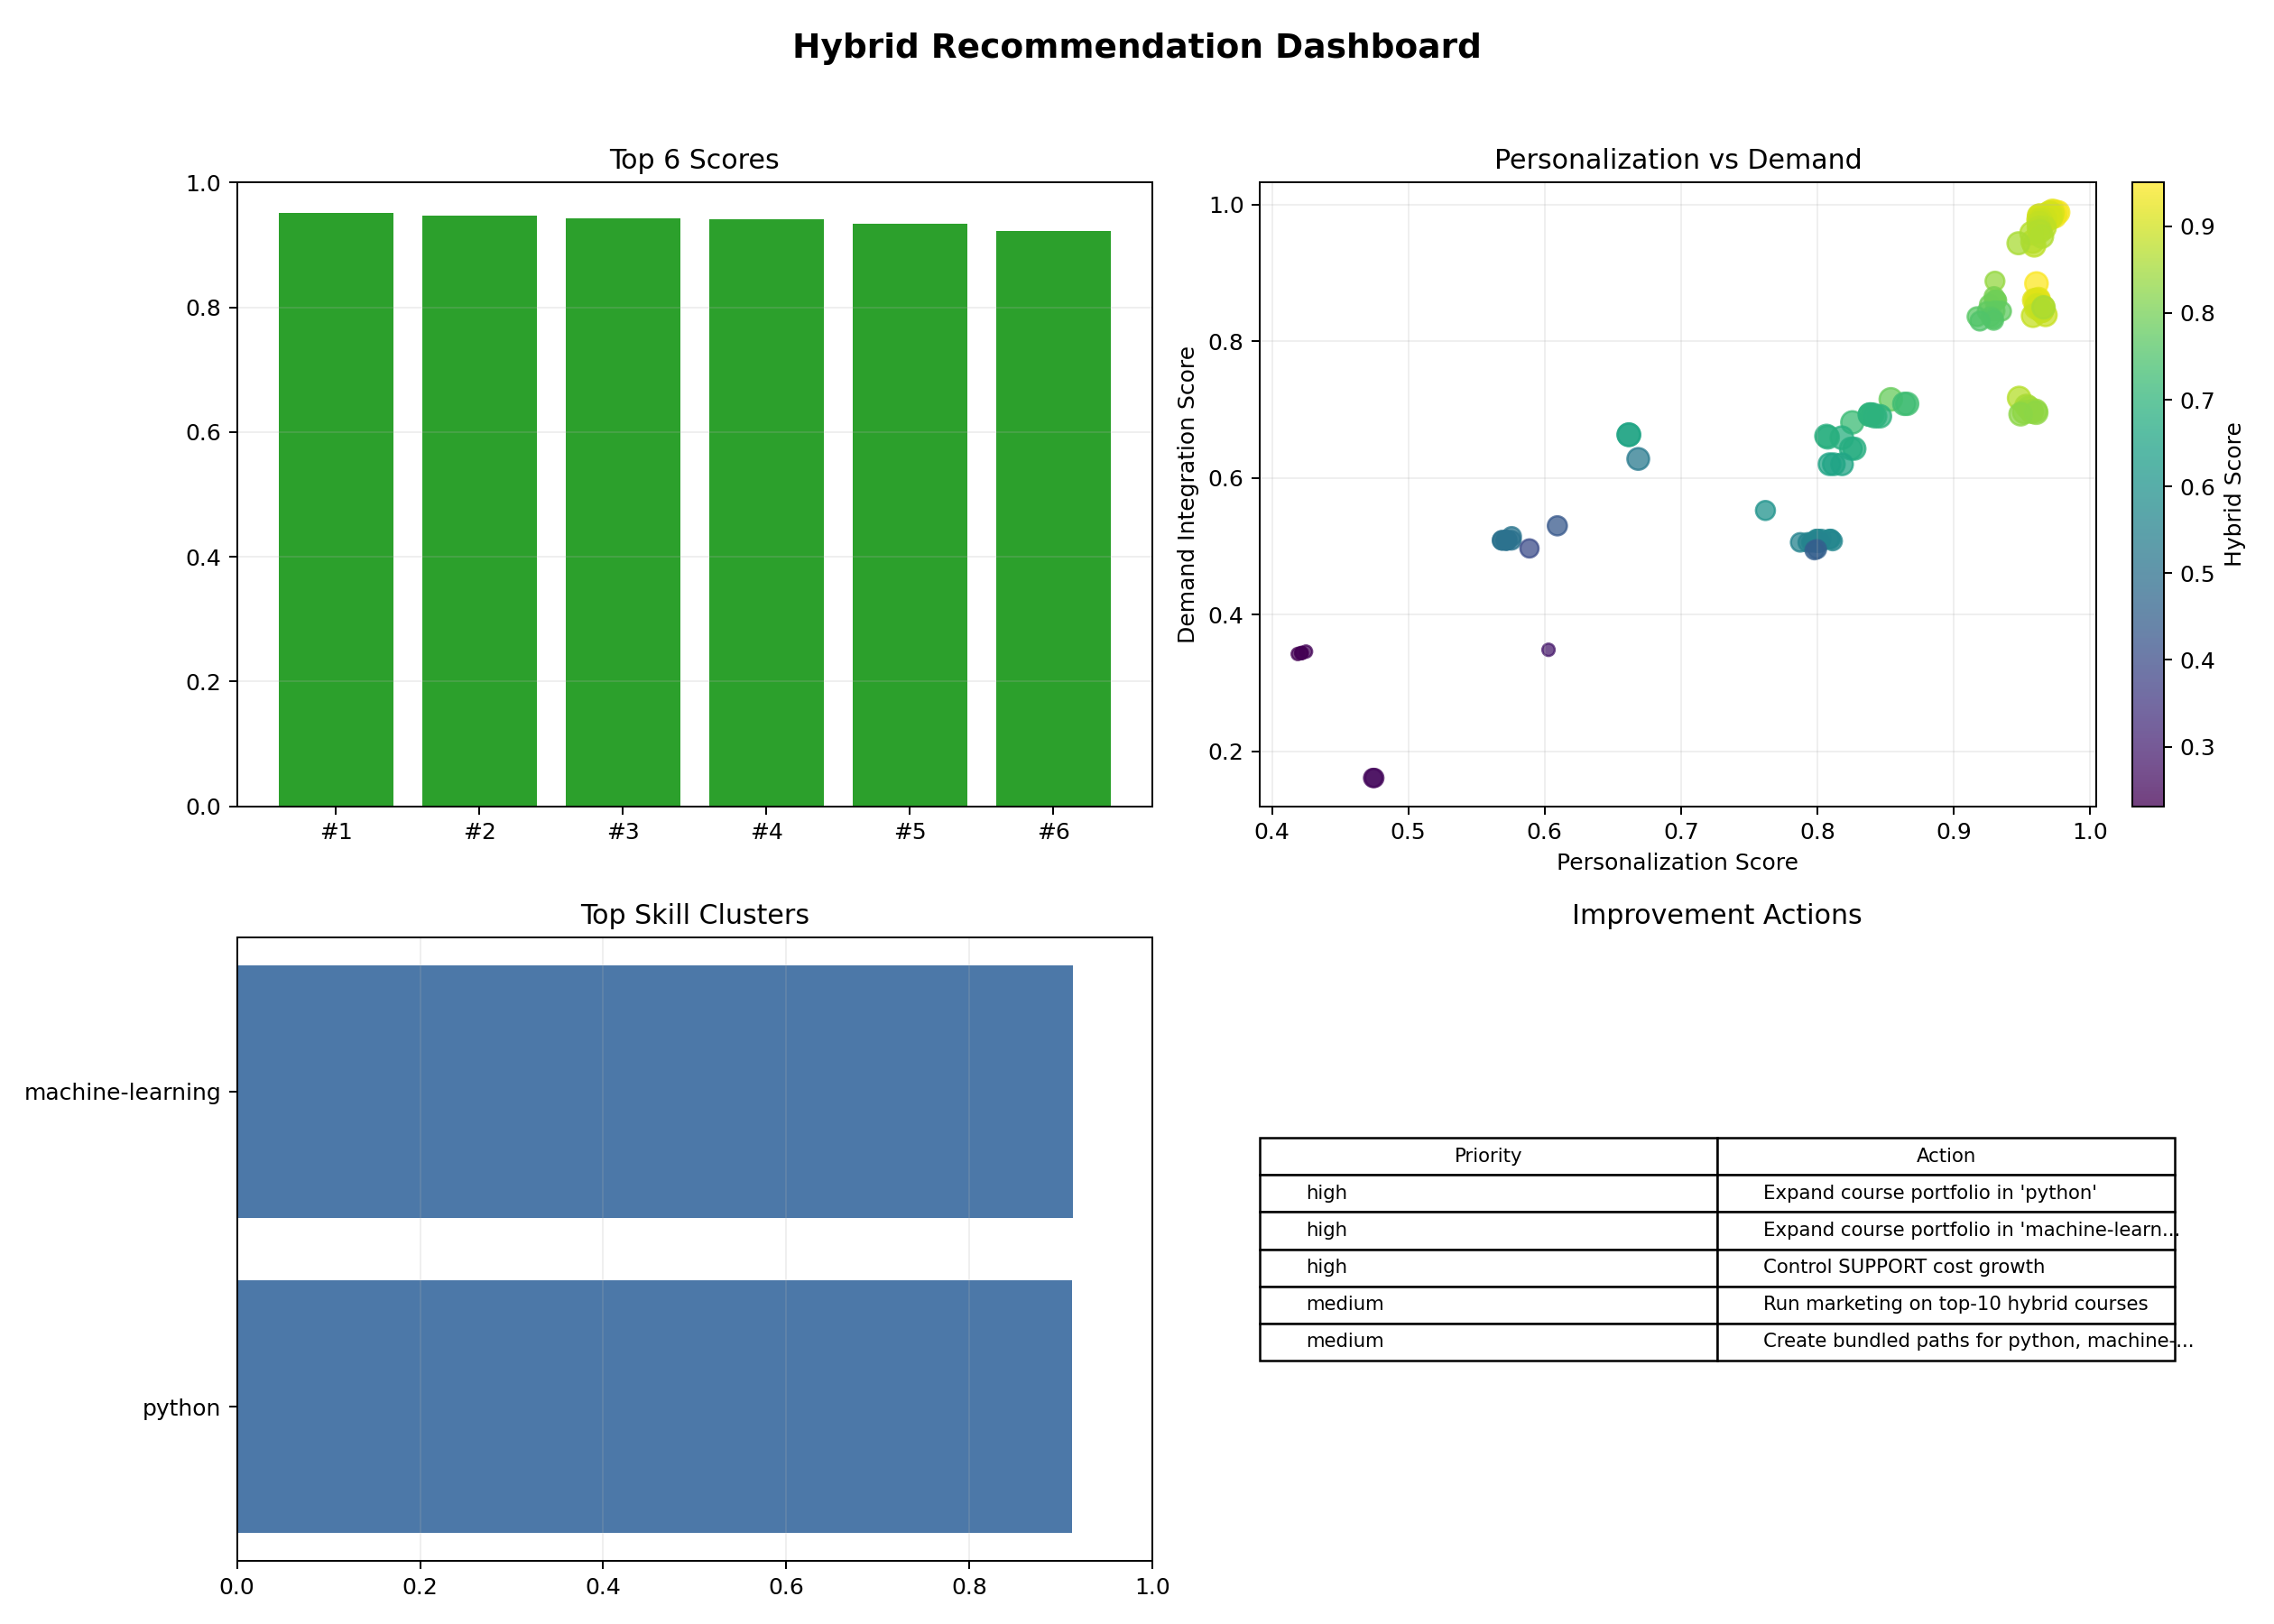

### recommendations_top10_scores.png

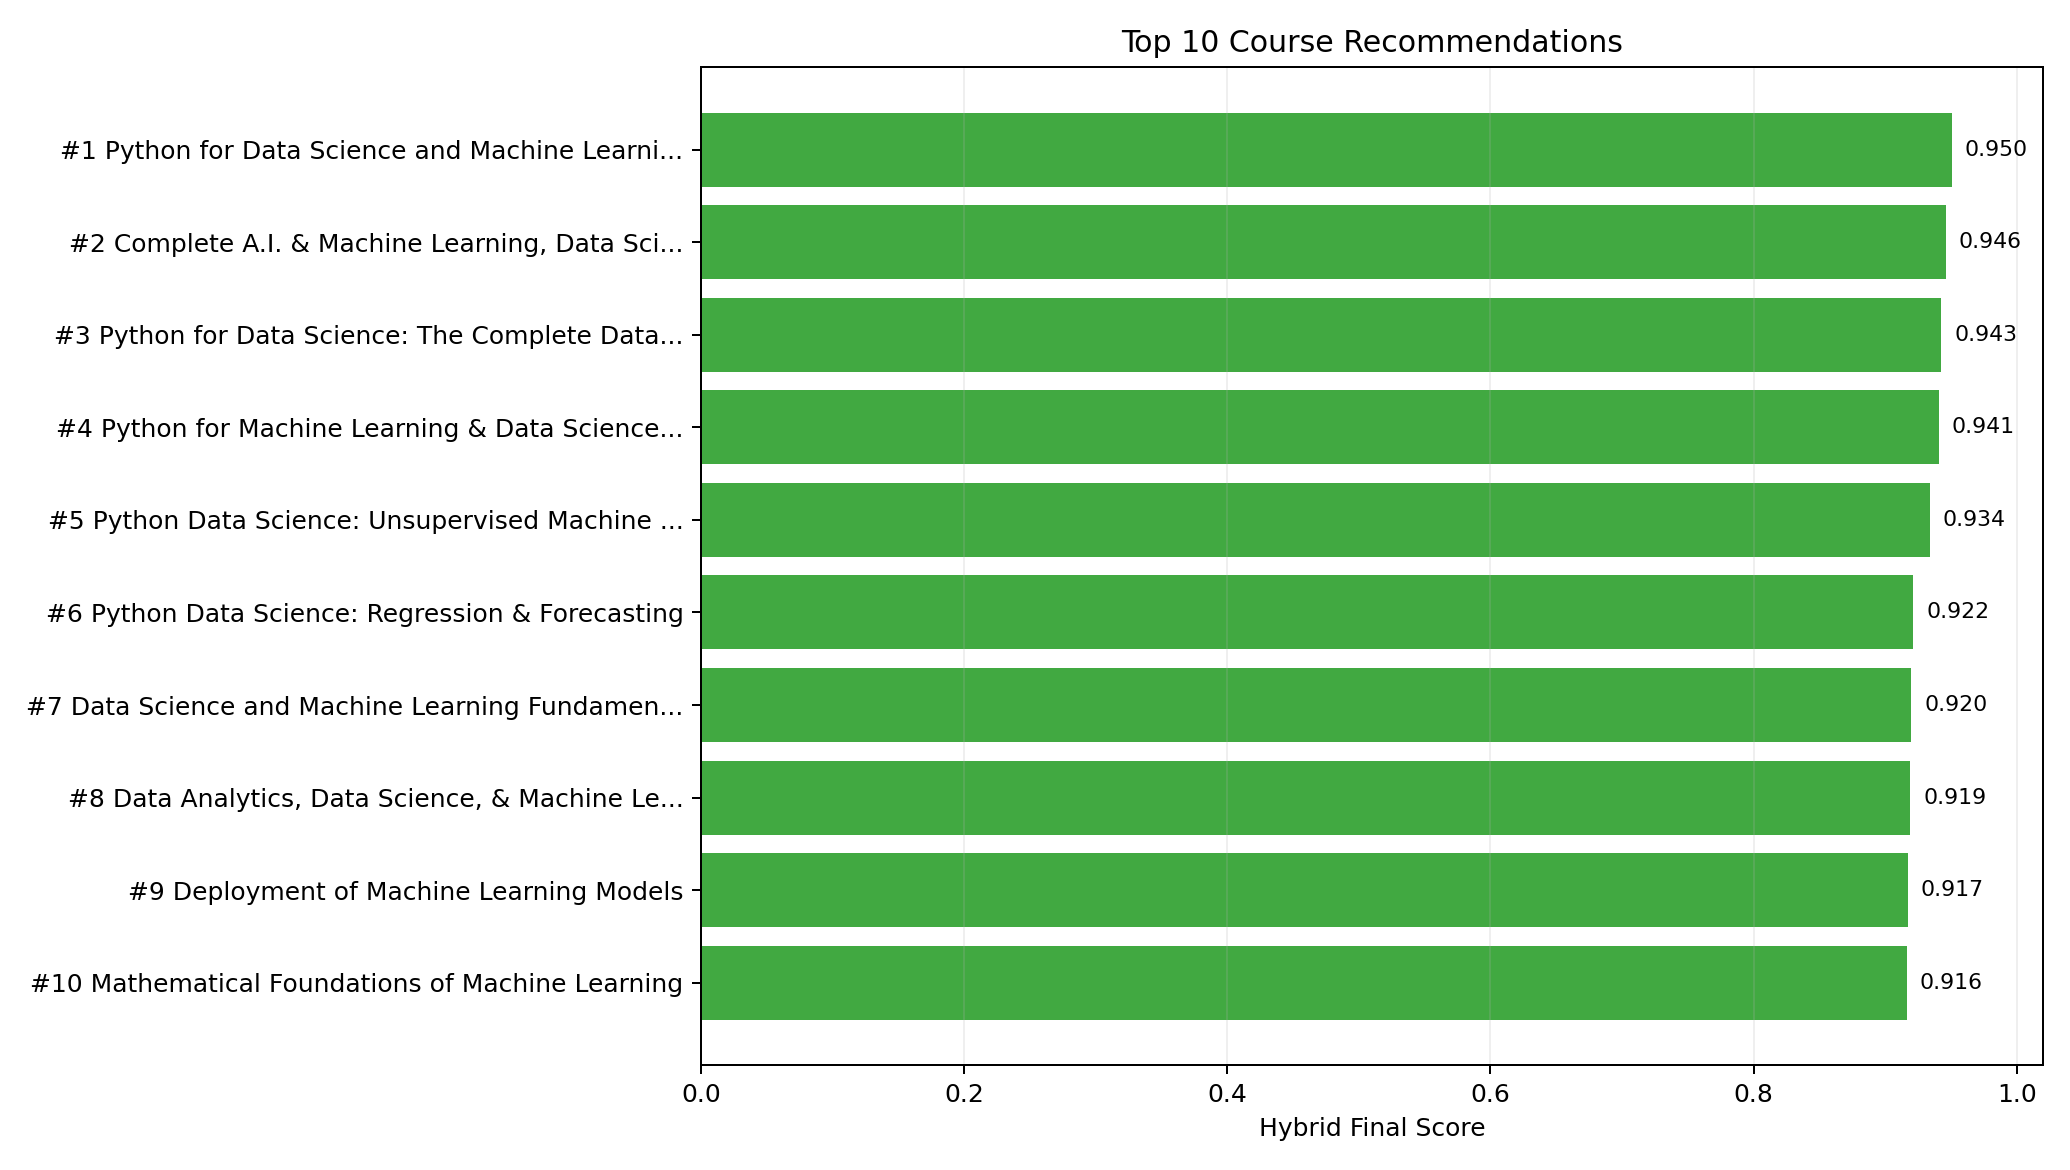

### recommendations_skill_clusters.png

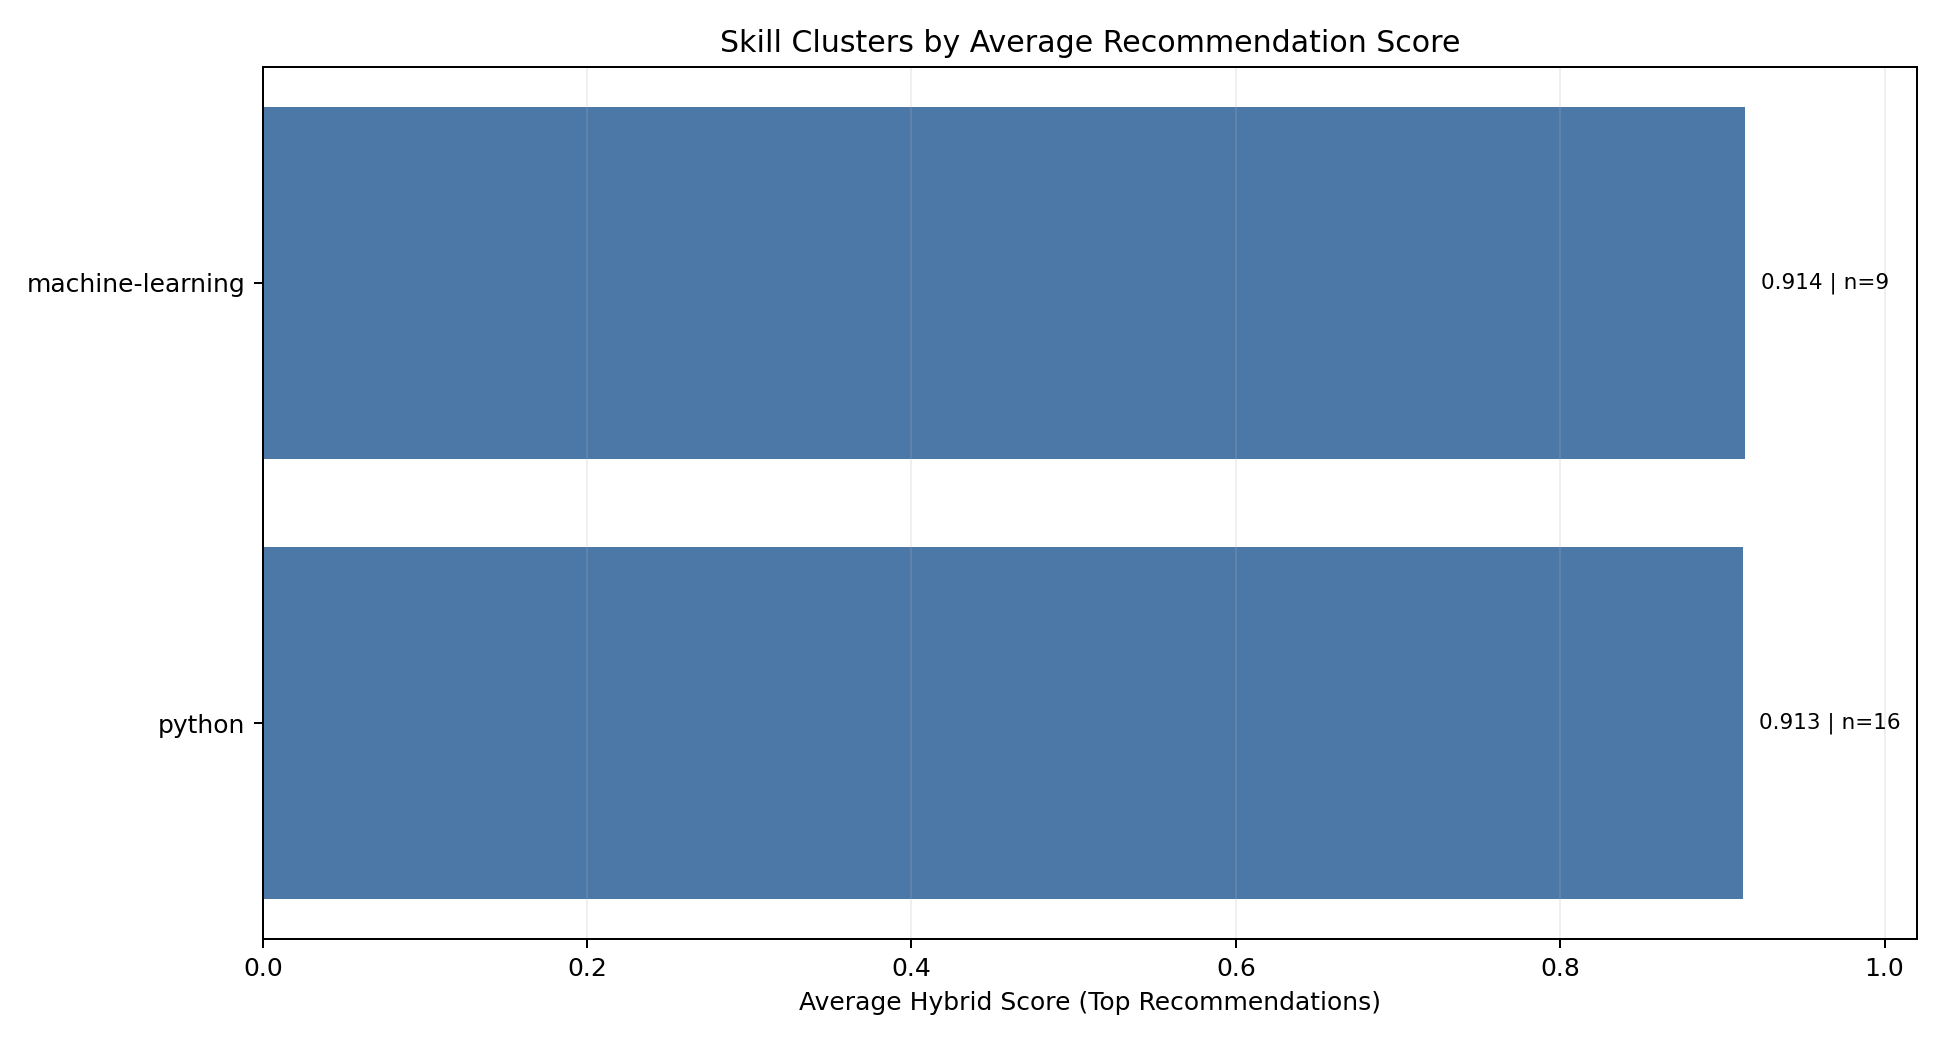

### recommendations_component_breakdown.png

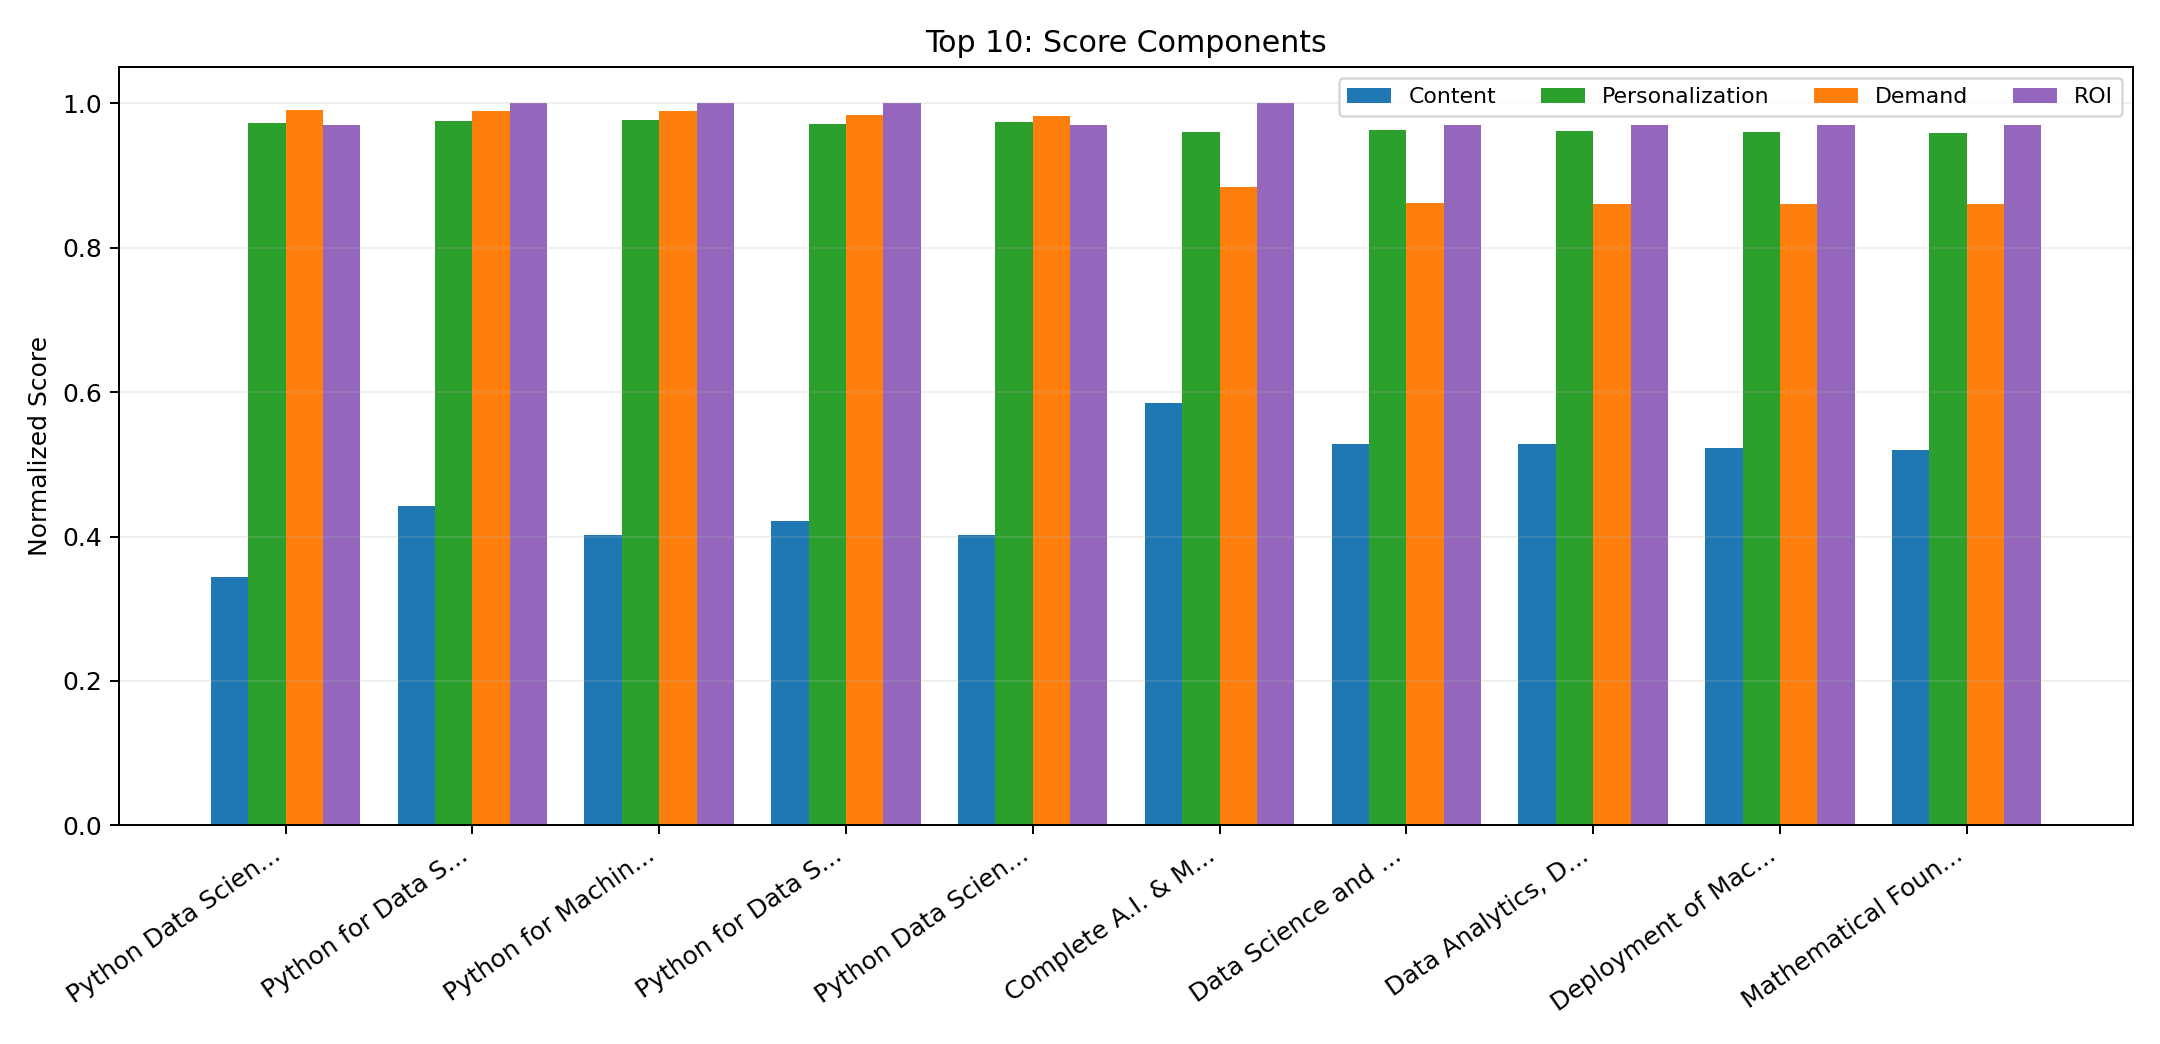

In [7]:
display(Markdown("## Dashboard Visuals"))
image_names = [
    "recommendations_dashboard.png",
    "recommendations_top10_scores.png",
    "recommendations_skill_clusters.png",
    "recommendations_component_breakdown.png",
]

for name in image_names:
    p = OUTPUT_DIR / name
    if p.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(p)))
    else:
        print(f"Missing: {p}")

In [8]:
display(Markdown("## JSON Summary (Optional)"))
summary_path = OUTPUT_DIR / "recommendations_hybrid_summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8"))
summary.keys()

## JSON Summary (Optional)

dict_keys(['forecast_context', 'input_files', 'algorithms', 'demand_integration_metrics', 'recommendation_scorecard', 'top_skill_clusters', 'improvement_actions', 'top_recommendations'])